### Middleware 

Middleware provides a way to more tightly control what happens inside the agent.Middleware is useful for the following:

- Tracking agent behaviour with logging,analytics ,and debugging.
- Transforming prompts,tool selection, and output formatting.
- Adding retries,fallbacks, and early termination logic.
- Applying rate limits , guardrails, and Pll detection.

Check out langchain in-built middleware documentation for more 
- https://reference.langchain.com/python/langchain/middleware

In [1]:
import os
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
from langchain.chat_models import init_chat_model
model = init_chat_model("google_genai:gemini-3.5-flash-lite")

### Summarization Middleware

Automatically summarize conversation history when approaching token limits,preserving recent messages while compressing older context. Summarization is useful for the following:

- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

1. Summarizing w.r.t the length of messages

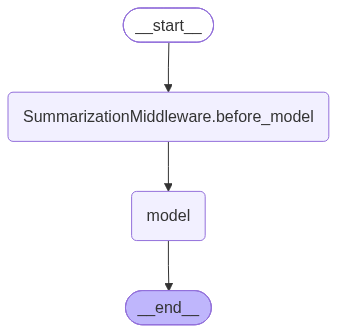

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import AIMessage,HumanMessage,SystemMessage

### agent with messagebased summarization

agent = create_agent(
    model= model,
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model =model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

In [6]:
## thread id
config = {"configurable":{"thread_id":"test1"}}

In [7]:
## alternative test data
questions =[
    "what is 2+2",
    "what is 19*3",
    "what is 100/2",
    "what is 3*4",
    "what is 5/8",
    "what is 4+3",
    ]
for q in questions :
    response = agent.invoke({"messages":[HumanMessage(content=q)]},config = config)
    print(f"Messages :{response}")
    print(f"Message length :{len(response["messages"])}")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Messages :{'messages': [HumanMessage(content='what is 2+2', additional_kwargs={}, response_metadata={}, id='5c91ef9d-29d6-492c-85f1-481afa2169d9'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4', 'extras': {'signature': 'El4KXAERTTIPYIQwVaYvdxV2gzxcsZiwmsbnVXdDufAFOXNm0KmfUTsL0VJKnDJsvJ4ddxgJMNPyYBn7C46pa/cISEOH7QliYL0PtAGTUcjHrGsz/4PgbXRzhIdNxTZK'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a05c2b-64f1-7903-9bcf-c67216291156-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 7, 'total_tokens': 14, 'input_token_details': {'cache_read': 0}})]}
Message length :2
Messages :{'messages': [HumanMessage(content='what is 2+2', additional_kwargs={}, response_metadata={}, id='5c91ef9d-29d6-492c-85f1-481afa2169d9'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4', 'extras': {'signature': 'El4KXAERTTIPYIQ

2. Summarizing w.r.t number of token size 

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [9]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~171 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='4316b79e-3bf4-48e6-b92b-5523d0e62f25'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_hotels', 'arguments': '{"city": "Paris"}'}, '__gemini_function_call_thought_signatures__': {'call_1149425': 'El4KXAERTTIPIc71MM6xbX3+Hk/DWYcESfIKeCl0/gqBABttdnPoOWdeIeIG909MNDHdf1EiG7IoiJ9s+pGI15ll3sTsDIZl6WRzrUygVarsuhE6ltAZvmJQBl3Uvy8G'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a05c32-8052-7e41-9fa8-abb03165f663-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_1149425', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 53, 'output_tokens': 16, 'total_tokens': 69, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='Hotels in Paris:\n    1. Grand Hotel - 5 star, $35

3. Using fraction

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)
config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gemini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~100 tokens (0.0781%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='9313f4db-9bfa-4a6c-b2e2-316faafedc3b'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_hotels', 'arguments': '{"city": "Paris"}'}, '__gemini_function_call_thought_signatures__': {'call_1137507': 'El4KXAERTTIPh2ZJ5a1ZrZRIx3YJQNLXgOvrkfU0QT4ZK5XcjRfL0aYOYw7gD/Mo+TUN/qcOdOCpbcStyjyokNTIiaRdG1C0QC7ZPIxoio805vhtWzEcPYewzOGlSNHr'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a05c38-976b-7463-a64a-48f2dcc1563e-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_1137507', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 16, 'total_tokens': 61, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='Hotels in Paris: Grand Hotel $350, City Inn $180,

### Human In The Loop Middleware



Pause agent execution for human approval,editing,or rejection of tool call before they execute.Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval(e.g. database writes,financial transactions).
- Compliance workflows where human oversight is mandatory
- Long-running conversations where human feedback guides the agent.

In [13]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

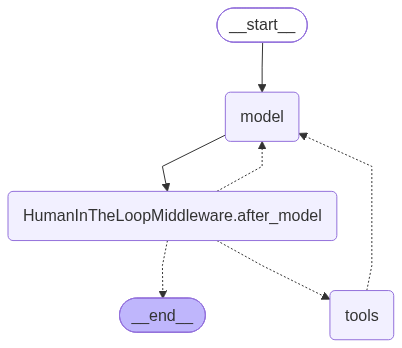

In [15]:

agent=create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)
agent

In [16]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [17]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='462475e5-2057-4785-ab43-f14382d3ac4f'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"recipient": "john@test.com", "subject": "Hello", "body": "How are you?"}'}, '__gemini_function_call_thought_signatures__': {'call_4378419': 'El4KXAERTTIPjsVR3prkHTAlrDX9SqRVlAlCLs78ZZWyqnE4QZEDY0xlg/yeystXQQC7xTl+ya2uHnnhZ7fz05AaZV8IbeaXtRC/0ZbgnGKNNjWLWIL9lJDs1AUzxz6w'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a05c40-2d55-7791-8867-b66a84618615-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_4378419', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 144, '

In [18]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: [{'type': 'text', 'text': "Email sent successfully to john@test.com with subject 'Hello'.", 'extras': {'signature': 'El4KXAERTTIP1x112UREiTuCyOqqgDLChWTlM/fcfC6+VTxsl5BvllZEgK2//4Uq5VCVFOOsaVpviukPcEBcgjjngLRZSE/vU2a+ja9YbUBzDuk/xtY6HGA1ly+GKnMv'}}]


In [19]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='462475e5-2057-4785-ab43-f14382d3ac4f'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"recipient": "john@test.com", "subject": "Hello", "body": "How are you?"}'}, '__gemini_function_call_thought_signatures__': {'call_4378419': 'El4KXAERTTIPjsVR3prkHTAlrDX9SqRVlAlCLs78ZZWyqnE4QZEDY0xlg/yeystXQQC7xTl+ya2uHnnhZ7fz05AaZV8IbeaXtRC/0ZbgnGKNNjWLWIL9lJDs1AUzxz6w'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a05c40-2d55-7791-8867-b66a84618615-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_4378419', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 144, '

### Reject

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent=create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)


In [26]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [27]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: [{'type': 'text', 'text': 'The email sending was rejected by the user. Let me know if you need help with anything else!', 'extras': {'signature': 'El4KXAERTTIP615VcJQm+7Ckj2CE+OoBTkyjmWWRErn/NIt4SRhKzIRtZ38UbtGK9zkAJSyNxCS2FRW03784LyzdMwlOnMheeu8DEobEglf2TasMGJWnvI4O2kvv+255'}}]


### Editing

In [28]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [29]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [31]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: [{'type': 'text', 'text': "Email sent to correct@email.com with subject 'Corrected Subject'", 'extras': {'signature': 'El4KXAERTTIPovZo9lpDycbOzKcXvZ8sZ4atxIdlphZ6y7XhRCd+PxDkWM67xOkGzjjFvxUBlTRlbDUaO8robwQqtr5HuP9Xx+Q59WSCKGzD5j1XKZFkl9505BZSf5/z'}}]
